In [1]:
# Imports and repo setup.
from pathlib import Path
from collections import Counter
import json
import os
import sys
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("XDG_CACHE_HOME", "/tmp")

import numpy as np
import torch

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "calvin_experiments" / "calvin_rollout_utils.py").exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError("Could not find guided-diffusion repo root")
    REPO_ROOT = REPO_ROOT.parent

for path in [REPO_ROOT, REPO_ROOT / "robomimic", REPO_ROOT / "calvin" / "calvin_env", REPO_ROOT / "calvin_experiments"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import robomimic.envs  # noqa: F401
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
import robomimic.utils.python_utils as PyUtils
import robomimic.utils.torch_utils as TorchUtils

from calvin_experiments import calvin_rollout_utils as CRU
from calvin_experiments.label_calvin_world_model import label_scene_states_for_names

print("repo:", REPO_ROOT)
print("cuda:", torch.cuda.is_available())


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


repo: /home/moritz/src/guided-diffusion
cuda: True


In [2]:
# Load the policy and automaton model; this conjunction experiment uses no dynamics model.
DEVICE = TorchUtils.get_torch_device(try_to_use_cuda=True)

POLICY_CKPT_PATH = REPO_ROOT / "outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth"
AUTOMATON_CKPT_PATH = REPO_ROOT / "outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38"
SCENE_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/blocks_hidden.json"
VISUALIZATION_CONFIG_PATH = REPO_ROOT / "calvin_experiments/configs/visualization_freiburg_style.json"
OUTPUT_ROOT = REPO_ROOT / "outputs/calvin/paper_stls/F_a_and_F_b"
VIDEO_FPS = 30

policy, ckpt_dict = FileUtils.policy_from_checkpoint(ckpt_path=str(POLICY_CKPT_PATH), device=DEVICE, verbose=False)
policy_epoch = CRU.policy_epoch_from_checkpoint(POLICY_CKPT_PATH)
scene_cfg = CRU.load_json_config(SCENE_CONFIG_PATH)
video_cfg = CRU.load_json_config(VISUALIZATION_CONFIG_PATH)

automaton_model, automaton_stats, automaton_meta = CRU.automaton_model_for_eval(AUTOMATON_CKPT_PATH, DEVICE)
label_names = list(automaton_meta["label_names"])
label_thresholds = automaton_meta.get("label_thresholds")

OPPOSITE_LABEL_NAMES = {
    "switch_on": "switch_off", "switch_off": "switch_on",
    "button_on": "button_off", "button_off": "button_on",
    "drawer_open": "drawer_closed", "drawer_closed": "drawer_open",
    "door_left": "door_right", "door_right": "door_left",
}

def validate_target_label_idx(target_label_idx):
    target_label_idx = int(target_label_idx)
    if target_label_idx < 0 or target_label_idx >= len(label_names):
        raise ValueError(f"target_label_idx must be in [0, {len(label_names) - 1}], got {target_label_idx}")
    return target_label_idx

def opposite_label_idx(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opposite_name = OPPOSITE_LABEL_NAMES.get(label_names[target_label_idx])
    if opposite_name is None or opposite_name not in label_names:
        return None
    return label_names.index(opposite_name)

def score_label_probs(label_probs, target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    scores = np.asarray(label_probs, dtype=np.float32)[..., target_label_idx].copy()
    opp = opposite_label_idx(target_label_idx)
    if opp is not None:
        scores -= np.asarray(label_probs, dtype=np.float32)[..., opp]
    return scores

def score_rule_name(target_label_idx):
    target_label_idx = validate_target_label_idx(target_label_idx)
    opp = opposite_label_idx(target_label_idx)
    if opp is None:
        return f"p({label_names[target_label_idx]})"
    return f"p({label_names[target_label_idx]}) - p({label_names[opp]})"

print("device:", DEVICE)
print("policy:", POLICY_CKPT_PATH)
print("automaton:", AUTOMATON_CKPT_PATH)
print("label order:")
for idx, name in enumerate(label_names):
    print(f"  {idx}: {name}  score={score_rule_name(idx)}")



============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['proprio']
using obs modality: rgb with keys: ['third_person', 'eye_in_hand']
using obs modality: depth with keys: []
using obs modality: scan with keys: []
number of parameters: 6.931892e+07
device: cuda:0
policy: /home/moritz/src/guided-diffusion/outputs/calvin/base_policy/calvin_D_base_dp/20260501015147/models/model_epoch_280.pth
automaton: /home/moritz/src/guided-diffusion/outputs/calvin/automaton_world_model/h8_sh64_ah96_lh16_hh128_lr0.0003_epochs80_2026-05-05_20-38-38
label order:
  0: switch_on  score=p(switch_on) - p(switch_off)
  1: switch_off  score=p(switch_off) - p(switch_on)
  2: button_on  score=p(button_on) - p(button_off)
  3: button_off  score=p(button_off) - p(button_on)
  4: button_pressed  score=p(button_pressed)
  5: drawer_open  score=p(drawer_open) - p(drawer_closed)
  6: drawer_closed  score=p(drawer_closed) - p(drawer_open)
  7: door_left  score=p(d

In [3]:
# Rollout helpers and automaton sample-and-rank utilities.
env = None
base_env_state = None

def robot_obs_with_target_xy(env, robot_obs, start_xy):
    import pybullet as p

    robot_obs = np.asarray(robot_obs, dtype=np.float32).copy()
    target_pos = robot_obs[:3].copy()
    target_pos[:2] = np.asarray(start_xy, dtype=np.float32)
    target_orn = p.getQuaternionFromEuler(robot_obs[3:6])

    robomimic_env = env.env if hasattr(env, "_get_initial_obs_history") else env
    gym_env = getattr(robomimic_env, "env", None)
    robot = getattr(gym_env, "robot", None)
    if robot is None or not hasattr(robot, "mixed_ik"):
        robot_obs[:2] = target_pos[:2]
        return robot_obs

    labels = robot.get_observation_labels()
    joint_indices = [i for i, name in enumerate(labels) if name.startswith("robot_joint")]
    joint_states = robot.mixed_ik.get_ik(target_pos, target_orn)
    robot_obs[:3] = target_pos
    robot_obs[joint_indices] = np.asarray(joint_states[:len(joint_indices)], dtype=np.float32)
    return robot_obs

def current_automaton_state_and_label(env):
    state = env.get_state()
    robot = np.asarray(state["robot"], dtype=np.float32).reshape(-1)
    scene = np.asarray(state["scene"], dtype=np.float32).reshape(-1)
    automaton_state = np.concatenate([robot, scene]).astype(np.float32)
    automaton_label = label_scene_states_for_names(scene[None, :], label_names, label_thresholds)[0].astype(np.float32)
    return automaton_state, automaton_label

def repeat_obs_batch(obs_tensor, n):
    if int(n) == 1:
        return obs_tensor
    return {key: value.repeat((int(n),) + (1,) * (value.ndim - 1)) for key, value in obs_tensor.items()}

def unnormalize_action_sequence(action_sequence):
    action_np = CRU.to_numpy(action_sequence).astype(np.float32)
    if policy.action_normalization_stats is None:
        return action_np
    original_shape = action_np.shape
    flat_actions = action_np.reshape(-1, original_shape[-1])
    action_keys = policy.policy.global_config.train.action_keys
    action_shapes = {key: policy.action_normalization_stats[key]["offset"].shape[1:] for key in policy.action_normalization_stats}
    action_dict = PyUtils.vector_to_action_dict(flat_actions, action_shapes=action_shapes, action_keys=action_keys)
    action_dict = ObsUtils.unnormalize_dict(action_dict, normalization_stats=policy.action_normalization_stats)
    return PyUtils.action_dict_to_vector(action_dict, action_keys=action_keys).reshape(original_shape)

def predict_future_label_probs(automaton_state, automaton_label, action_chunks):
    action_chunks = np.asarray(action_chunks, dtype=np.float32)
    n_candidates, _, action_dim = action_chunks.shape
    automaton_horizon = len(automaton_stats["actions_mean"]) // action_dim
    scored_chunks = action_chunks[:, :automaton_horizon, :].reshape(n_candidates, -1)
    states = np.repeat(np.asarray(automaton_state, dtype=np.float32)[None, :], n_candidates, axis=0)
    labels = np.repeat(np.asarray(automaton_label, dtype=np.float32)[None, :], n_candidates, axis=0)
    states_t = torch.as_tensor((states - automaton_stats["states_mean"]) / automaton_stats["states_std"], device=DEVICE, dtype=torch.float32)
    actions_t = torch.as_tensor((scored_chunks - automaton_stats["actions_mean"]) / automaton_stats["actions_std"], device=DEVICE, dtype=torch.float32)
    labels_t = torch.as_tensor(labels, device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        probs = torch.sigmoid(automaton_model(states_t, actions_t, labels_t)).detach().cpu().numpy()
    return probs, automaton_horizon

def rollout_policy_once(seed, action_sampler, output_dir, rollout_tag, horizon=350, save_video=True, stop_when_complete=True, start_xy=None):
    global env, base_env_state
    CRU.drop_env_quietly(globals(), name="env")
    env, base_env_state = CRU.load_fresh_env_from_checkpoint(ckpt_dict, seed=int(seed), suppress_output=True)
    fixed_scene, fixed_robot, active_scene_cfg = CRU.fixed_scene_robot_from_config(base_env_state, SCENE_CONFIG_PATH)
    if start_xy is not None:
        fixed_robot = robot_obs_with_target_xy(env, fixed_robot, start_xy)

    CRU.seed_everything(seed)
    policy.start_episode()
    obs = CRU.reset_env_to_scene_robot(env, fixed_scene, fixed_robot)
    scene_snapshot = CRU.capture_scene_snapshot(env)
    frames = [CRU.render_visual_camera(env, video_cfg)] if save_video else []

    start_state = env.get_state()
    start_scene = np.asarray(start_state["scene"], dtype=np.float32).copy()
    binaries = CRU.articulated_binaries_from_start_state(start_scene)
    _, label0 = current_automaton_state_and_label(env)
    if hasattr(action_sampler, "sync"):
        action_sampler.sync(label0, 0)

    actions, rewards, dones, records = [], [], [], []
    scene_states = [start_scene.copy()]
    robot_states = [np.asarray(start_state["robot"], dtype=np.float32).copy()]
    eef_xy = [robot_states[-1][:2].copy()]
    action_queue = []
    first_behavior, first_behavior_step = "none", -1
    termination_reason = "horizon"

    for step in range(int(horizon)):
        if not action_queue:
            new_actions, record = action_sampler(obs, env, step)
            action_queue.extend(np.asarray(new_actions, dtype=np.float32))
            records.append(record)
        action = np.asarray(action_queue.pop(0), dtype=np.float32).copy()
        actions.append(action.copy())

        obs, reward, done, _ = env.step(action)
        state = env.get_state()
        scene = np.asarray(state["scene"], dtype=np.float32).copy()
        robot = np.asarray(state["robot"], dtype=np.float32).copy()
        _, current_label = current_automaton_state_and_label(env)

        rewards.append(float(reward)); dones.append(bool(done))
        scene_states.append(scene); robot_states.append(robot); eef_xy.append(robot[:2].copy())
        if save_video:
            frames.append(CRU.render_visual_camera(env, video_cfg))

        if first_behavior_step < 0 and CRU.check_state_difference(start_scene, scene, robot[:3], binaries, for_display=False):
            first_behavior = CRU.classify_behavior(start_scene, scene, robot[:3], binaries, for_display=False)
            first_behavior_step = step + 1

        if hasattr(action_sampler, "sync"):
            events_before = len(action_sampler.events)
            advanced = action_sampler.sync(current_label, step + 1)
            if advanced:
                action_queue.clear()
            if stop_when_complete and action_sampler.done:
                termination_reason = "and_target_complete"
                break
        if done:
            termination_reason = "env_done"
            break

    _, labelf = current_automaton_state_and_label(env)
    complete = bool(getattr(action_sampler, "done", False))
    rollout = {
        "scene_config": active_scene_cfg["name"], "seed": int(seed),
        "start_xy": None if start_xy is None else [float(start_xy[0]), float(start_xy[1])],
        "behavior": "and_complete" if complete else first_behavior,
        "first_behavior": first_behavior, "first_behavior_step": int(first_behavior_step),
        "behavior_step": int(action_sampler.events[-1]["step"] if getattr(action_sampler, "events", []) else first_behavior_step),
        "termination_step": len(actions), "termination_reason": termination_reason,
        "return": float(np.sum(rewards)), "actions": np.asarray(actions, dtype=np.float32),
        "rewards": np.asarray(rewards, dtype=np.float32), "dones": np.asarray(dones, dtype=bool),
        "scene_states": np.asarray(scene_states, dtype=np.float32), "robot_states": np.asarray(robot_states, dtype=np.float32),
        "eef_xy": np.asarray(eef_xy, dtype=np.float32), "initial_label": label0.astype(int).tolist(),
        "final_label": labelf.astype(int).tolist(), "records": records,
        "target_events": list(getattr(action_sampler, "events", [])), "and_complete": complete,
        "scene_snapshot": scene_snapshot,
    }
    if save_video:
        CRU.save_rollout_artifacts(rollout, frames, output_dir, rollout_tag, video_cfg, fps=VIDEO_FPS)
    return rollout


In [4]:
# Conjunction samplers: direct min-score baseline and remaining-targets strategy.
def target_idxs_from_names(target_names):
    fixed_names = []
    for name in target_names:
        if isinstance(name, str) and "," in name:
            fixed_names.extend(part.strip() for part in name.split(",") if part.strip())
        else:
            fixed_names.append(name)
    missing = [name for name in fixed_names if name not in label_names]
    if missing:
        raise ValueError(f"Targets not in loaded automaton labels: {missing}; labels={label_names}")
    return [label_names.index(name) for name in fixed_names]

def sync_target_events(label, step, target_idxs, achieved, events):
    advanced = False
    for idx in target_idxs:
        if idx not in achieved and float(label[idx]) > 0.5:
            achieved.add(idx)
            events.append({"step": int(step), "target_idx": int(idx), "target_name": label_names[idx]})
            advanced = True
    return advanced

def make_min_and_sample_rank_action_provider(target_idxs, n_candidates):
    target_idxs = [validate_target_label_idx(idx) for idx in target_idxs]
    n_candidates = int(n_candidates)
    achieved, events = set(), []

    def sync(label, step):
        advanced = sync_target_events(label, step, target_idxs, achieved, events)
        action_provider.events = events
        action_provider.done = len(achieved) == len(target_idxs)
        return advanced

    def action_provider(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        sync(automaton_label, step)
        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)

        target_score_columns = np.stack([score_label_probs(candidate_probs, idx) for idx in target_idxs], axis=1)
        candidate_scores = target_score_columns.min(axis=1)
        limiting_target_pos = target_score_columns.argmin(axis=1)
        selected_idx = int(np.argmax(candidate_scores))
        selected_limiting_idx = int(target_idxs[int(limiting_target_pos[selected_idx])])

        record = {
            "t": int(step), "mode": "min_and", "target_idxs": [int(idx) for idx in target_idxs],
            "target_names": [label_names[idx] for idx in target_idxs], "achieved_names": [label_names[idx] for idx in sorted(achieved)],
            "current_label": automaton_label.astype(int).tolist(), "selected_idx": selected_idx,
            "selected_score": float(candidate_scores[selected_idx]),
            "limiting_target_idx": selected_limiting_idx, "limiting_target_name": label_names[selected_limiting_idx],
            "selected_target_scores": {label_names[idx]: float(target_score_columns[selected_idx, pos]) for pos, idx in enumerate(target_idxs)},
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
        }
        return np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32), record

    action_provider.sync = sync
    action_provider.done = False
    action_provider.events = events
    return action_provider

def make_remaining_or_action_provider(target_idxs, n_candidates):
    target_idxs = [validate_target_label_idx(idx) for idx in target_idxs]
    n_candidates = int(n_candidates)
    achieved, events = set(), []

    def sync(label, step):
        advanced = sync_target_events(label, step, target_idxs, achieved, events)
        action_provider.events = events
        action_provider.done = len(achieved) == len(target_idxs)
        return advanced

    def action_provider(obs, env, step):
        automaton_state, automaton_label = current_automaton_state_and_label(env)
        sync(automaton_label, step)
        remaining = [idx for idx in target_idxs if idx not in achieved]
        if not remaining:
            remaining = [target_idxs[-1]]

        obs_tensor = policy._prepare_observation(obs)
        obs_tensor_rank = repeat_obs_batch(obs_tensor, n_candidates)
        with torch.no_grad():
            action_chunk_n = policy.policy._get_action_trajectory(obs_dict=obs_tensor_rank)
        action_chunks = unnormalize_action_sequence(action_chunk_n)
        candidate_probs, automaton_horizon = predict_future_label_probs(automaton_state, automaton_label, action_chunks)

        remaining_score_columns = np.stack([score_label_probs(candidate_probs, idx) for idx in remaining], axis=1)
        candidate_scores = remaining_score_columns.max(axis=1)
        candidate_target_pos = remaining_score_columns.argmax(axis=1)
        selected_idx = int(np.argmax(candidate_scores))
        selected_target_idx = int(remaining[int(candidate_target_pos[selected_idx])])

        record = {
            "t": int(step), "mode": "remaining_or", "target_idxs": [int(idx) for idx in target_idxs],
            "target_names": [label_names[idx] for idx in target_idxs], "remaining_names": [label_names[idx] for idx in remaining],
            "achieved_names": [label_names[idx] for idx in sorted(achieved)],
            "current_label": automaton_label.astype(int).tolist(), "selected_idx": selected_idx,
            "selected_score": float(candidate_scores[selected_idx]),
            "selected_target_idx": selected_target_idx, "selected_target_name": label_names[selected_target_idx],
            "selected_remaining_scores": {label_names[idx]: float(remaining_score_columns[selected_idx, pos]) for pos, idx in enumerate(remaining)},
            "pred_probs": candidate_probs[selected_idx].tolist(), "candidate_scores": candidate_scores.tolist(),
        }
        return np.asarray(action_chunks[selected_idx, :automaton_horizon, :], dtype=np.float32), record

    action_provider.sync = sync
    action_provider.done = False
    action_provider.events = events
    return action_provider


In [51]:
SEEDS = [0]
START_XS = [0.0,  0.1]
START_YS = [-0.2, -0.1]
START_XY_LIST = [(x, y) for x in START_XS for y in START_YS]
AND_TARGET_NAMES = ["switch_on", "button_on"]
AND_TARGET_IDXS = target_idxs_from_names(AND_TARGET_NAMES)
N_CANDIDATES = 64
HORIZON = 300
SAVE_VIDEO = True

In [52]:
# Shared experiment knobs. Defaults match the current F a OR F b test setup.

def start_xy_tag(start_xy):
    return f"x{start_xy[0]:.2f}_y{start_xy[1]:.2f}".replace("-", "m").replace(".", "p")

def run_and_batch(mode_name, sampler_factory):
    run_dir = OUTPUT_ROOT / f"{mode_name}_{time.strftime('%Y%m%d_%H%M%S')}"
    run_dir.mkdir(parents=True, exist_ok=False)
    rollouts = []
    for start_idx, start_xy in enumerate(START_XY_LIST):
        for seed in SEEDS:
            action_sampler = sampler_factory(AND_TARGET_IDXS, N_CANDIDATES)
            rollout = rollout_policy_once(
                seed=seed,
                action_sampler=action_sampler,
                output_dir=run_dir,
                rollout_tag=f"{mode_name}_{'_and_'.join(AND_TARGET_NAMES)}_start{start_idx:02d}_{start_xy_tag(start_xy)}_seed_{seed:03d}",
                horizon=HORIZON,
                save_video=SAVE_VIDEO,
                stop_when_complete=True,
                start_xy=start_xy,
            )
            rollouts.append(rollout)
            events = ", ".join(f"{e['target_name']}@{e['step']}" for e in rollout["target_events"])
            print(
                f"{mode_name} start=({start_xy[0]:+.2f},{start_xy[1]:+.2f}) seed {seed:03d}: "
                f"complete={rollout['and_complete']}, steps={rollout['termination_step']:>3}, events=[{events}], video={rollout.get('video')}"
            )

    summary = {
        "mode": mode_name,
        "formula": " && ".join(f"F {name}" for name in AND_TARGET_NAMES),
        "and_target_names": AND_TARGET_NAMES, "and_target_idxs": AND_TARGET_IDXS,
        "score_rules": [score_rule_name(idx) for idx in AND_TARGET_IDXS],
        "seeds": SEEDS, "start_xy_list": [[float(x), float(y)] for x, y in START_XY_LIST],
        "n_candidates": N_CANDIDATES, "horizon": HORIZON,
        "n_rollouts": len(rollouts),
        "and_complete_rate": sum(r["and_complete"] for r in rollouts) / max(1, len(rollouts)),
        "event_count_patterns": {
            " -> ".join(pattern) if pattern else "none": count
            for pattern, count in Counter(tuple(e["target_name"] for e in r["target_events"]) for r in rollouts).items()
        },
        "rollouts": [
            {
                "seed": r["seed"], "start_xy": r["start_xy"], "and_complete": r["and_complete"],
                "target_events": r["target_events"], "termination_step": r["termination_step"],
                "termination_reason": r["termination_reason"], "initial_label": r["initial_label"], "final_label": r["final_label"],
                "video": None if "video" not in r else str(r["video"]), "trace": None if "trace" not in r else str(r["trace"]),
            }
            for r in rollouts
        ],
    }
    (run_dir / "summary.json").write_text(json.dumps(summary, indent=2))
    print(json.dumps({k: v for k, v in summary.items() if k != "rollouts"}, indent=2))
    print("run_dir:", run_dir)
    return rollouts, summary, run_dir


In [53]:
# Baseline attempt: direct conjunction via min(score_a, score_b).
# min_and_rollouts, min_and_summary, min_and_run_dir = run_and_batch(
#     "min_and",
#     make_min_and_sample_rank_action_provider,
# )


In [54]:
# Plot the direct min(score_a, score_b) conjunction attempt.
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from IPython.display import Image, display
import matplotlib.pyplot as plt

def plot_rollout_xy_time_gradient(rollouts, scene_snapshot, title, save_path=None, cmap_name="plasma"):
    paths = [np.asarray(r["eef_xy"], dtype=np.float32) for r in rollouts]
    max_step = max(max(1, len(path) - 1) for path in paths)
    norm = Normalize(vmin=0, vmax=max_step)
    cmap = plt.get_cmap(cmap_name)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_facecolor("#fbf7ef")
    CRU.draw_scene_snapshot(ax, scene_snapshot)

    for rollout, xy in zip(rollouts, paths):
        if len(xy) >= 2:
            segments = np.stack([xy[:-1], xy[1:]], axis=1)
            lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=2.3, alpha=0.82)
            lc.set_array(np.arange(len(segments), dtype=np.float32))
            ax.add_collection(lc)
        ax.scatter(xy[0, 0], xy[0, 1], c="white", s=46, edgecolors="black", linewidths=0.9, zorder=5)
        ax.scatter(xy[-1, 0], xy[-1, 1], c="black", s=42, edgecolors="white", linewidths=0.7, zorder=5)
        ax.text(xy[-1, 0] + 0.004, xy[-1, 1] + 0.004, f"s{rollout['seed']}", fontsize=8, color="black")
        for event in rollout.get("target_events", []):
            step = min(int(event["step"]), len(xy) - 1)
            ax.scatter(xy[step, 0], xy[step, 1], marker="*", s=115, c=[cmap(norm(step))], edgecolors="black", linewidths=0.7, zorder=6)
            ax.text(xy[step, 0] + 0.004, xy[step, 1] - 0.010, event["target_name"], fontsize=7, color="black")

    all_xy = np.concatenate(paths, axis=0)
    xlim, ylim = CRU.scene_limits_from_snapshot(scene_snapshot, all_xy)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("world x [m]"); ax.set_ylabel("world y [m]")
    ax.grid(alpha=0.3)
    cbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("rollout step")
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches="tight")
        print("plot:", save_path)
        plt.close(fig)
        display(Image(filename=str(save_path)))
    else:
        plt.show()

# plot_rollout_xy_time_gradient(
#     min_and_rollouts,
#     min_and_rollouts[0]["scene_snapshot"],
#     title=f"Direct min conjunction | N={len(min_and_rollouts)}, candidates={N_CANDIDATES}\n{' AND '.join('F ' + name for name in AND_TARGET_NAMES)}",
#     save_path=min_and_run_dir / "rollouts_xy_time_gradient.png",
# )


In [55]:
# Better attempt: repeatedly OR over remaining targets, removing targets once achieved.
remaining_or_rollouts, remaining_or_summary, remaining_or_run_dir = run_and_batch(
    "remaining_or_and",
    make_remaining_or_action_provider,
)


ven = NVIDIA Corporation
ven = NVIDIA Corporation
remaining_or_and start=(+0.00,-0.20) seed 000: complete=True, steps=197, events=[button_on@26, switch_on@197], video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_a_and_F_b/remaining_or_and_20260507_190152/remaining_or_and_switch_on_and_button_on_start00_x0p00_ym0p20_seed_000/blocks_hidden_remaining_or_and_switch_on_and_button_on_start00_x0p00_ym0p20_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
remaining_or_and start=(+0.00,-0.10) seed 000: complete=True, steps=268, events=[button_on@208, switch_on@268], video=/home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_a_and_F_b/remaining_or_and_20260507_190152/remaining_or_and_switch_on_and_button_on_start01_x0p00_ym0p10_seed_000/blocks_hidden_remaining_or_and_switch_on_and_button_on_start01_x0p00_ym0p10_seed_000_freiburg_style.mp4
ven = NVIDIA Corporation
ven = NVIDIA Corporation
remaining_or_and start=(+0.10,-0.20) seed 000: complete

plot: /home/moritz/src/guided-diffusion/outputs/calvin/paper_stls/F_a_and_F_b/remaining_or_and_20260507_190152/rollouts_xy_time_gradient.png


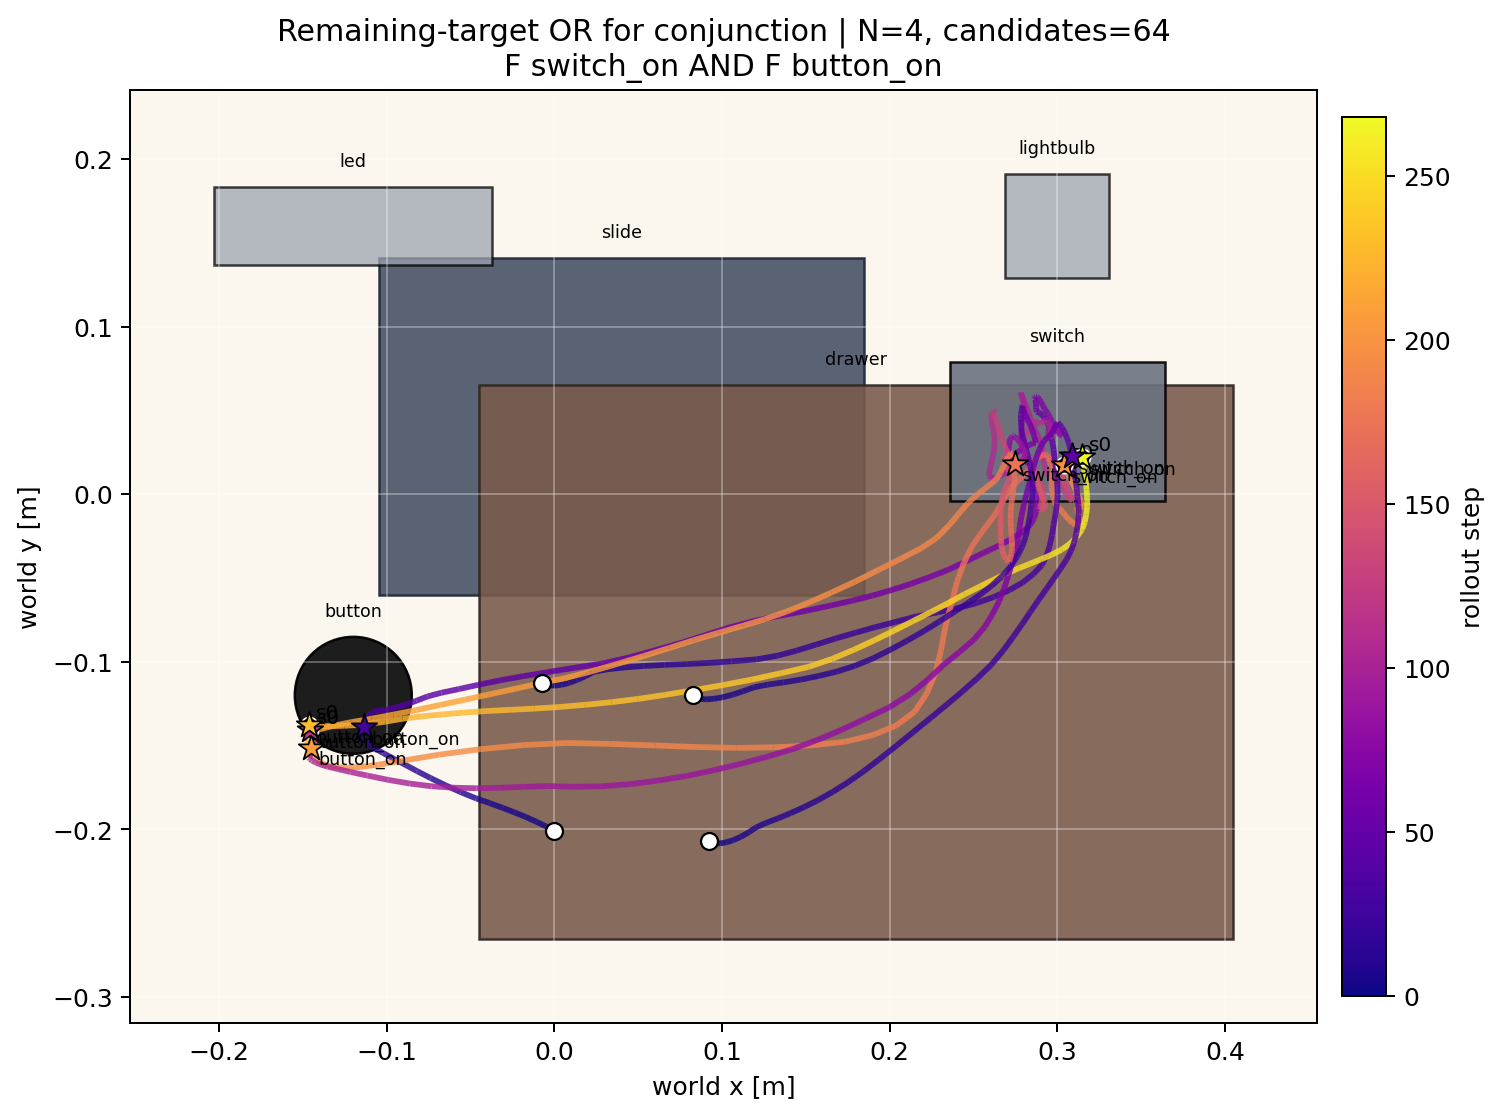

first selected chunks:
{'seed': 0, 'start_xy': [0.0, -0.2], 't': 0, 'mode': 'remaining_or', 'remaining': ['switch_on', 'button_on'], 'achieved': [], 'selected_target': 'button_on', 'score': -0.022791266441345215}
{'seed': 0, 'start_xy': [0.0, -0.2], 't': 8, 'mode': 'remaining_or', 'remaining': ['switch_on', 'button_on'], 'achieved': [], 'selected_target': 'button_on', 'score': 0.1346251368522644}
{'seed': 0, 'start_xy': [0.0, -0.2], 't': 16, 'mode': 'remaining_or', 'remaining': ['switch_on', 'button_on'], 'achieved': [], 'selected_target': 'button_on', 'score': 0.3330131769180298}
{'seed': 0, 'start_xy': [0.0, -0.2], 't': 24, 'mode': 'remaining_or', 'remaining': ['switch_on', 'button_on'], 'achieved': [], 'selected_target': 'button_on', 'score': 0.07216203212738037}
{'seed': 0, 'start_xy': [0.0, -0.2], 't': 26, 'mode': 'remaining_or', 'remaining': ['switch_on'], 'achieved': ['button_on'], 'selected_target': 'switch_on', 'score': -0.7292650938034058}
{'seed': 0, 'start_xy': [0.0, -0.2],

In [57]:
# Plot the remaining-targets conjunction strategy and inspect chunk choices.
plot_rollout_xy_time_gradient(
    remaining_or_rollouts,
    remaining_or_rollouts[0]["scene_snapshot"],
    title=f"Remaining-target OR for conjunction | N={len(remaining_or_rollouts)}, candidates={N_CANDIDATES}\n{' AND '.join('F ' + name for name in AND_TARGET_NAMES)}",
    save_path=remaining_or_run_dir / "rollouts_xy_time_gradient.png",
)

rows = []
for rollout in remaining_or_rollouts:
    for record in rollout.get("records", []):
        rows.append({
            "seed": rollout["seed"], "start_xy": rollout["start_xy"], "t": record["t"], "mode": record["mode"],
            "remaining": record.get("remaining_names"), "achieved": record.get("achieved_names"),
            "selected_target": record.get("selected_target_name"), "score": record["selected_score"],
        })

print("first selected chunks:")
for row in rows[:30]:
    print(row)

CRU.drop_env_quietly(globals(), name="env")
